# Columns
- `id` title unique id
- `rating` title rating (float, 1 decimal)
- `rating_category` 5 categories that summarize `rating`
  - `Low` from 0 to 4
  - `Medium low` from 4.1 to 5.5
  - `Medium` from 5.6 to 6.5
  - `Medium high` from 6.6 to 7
  - `High` from 7.1 to k
- `genre` genres of the title.
- `time series` Represents the domestic daily gross income of movies at the box office, starting from their release date (k0 features).
  - horizzontally
  - univariate

In [32]:
import pandas as pd

In [33]:
# load original_ds/imdb_ts.csv
df = pd.read_csv('../original_ds/imdb_ts.csv')

In [34]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1134
Number of columns: 104


In [35]:
print("5 random IDs:")
print(df['id'].sample(5).tolist())

5 random IDs:
['tt4846340', 'tt8477134', 'tt2932536', 'tt11128440', 'tt10954600']


In [36]:
print("Columns without numbers in their names:")
print([col for col in df.columns if not any(char.isdigit() for char in col)])

Columns without numbers in their names:
['id', 'rating', 'genre', 'rating_category']


In [37]:
# print number of unique values in each column if below 20
for col in df.columns:
    if df[col].nunique() < 20:
        print(f"{col}: {df[col].nunique()} unique values")

rating_category: 5 unique values


In [38]:
# for each rating_category, print the min and max values in rating 
for rating_category in df['rating_category'].unique():
    min_rating = df[df['rating_category'] == rating_category]['rating'].min()
    max_rating = df[df['rating_category'] == rating_category]['rating'].max()
    print(f"{rating_category}: min {min_rating}, max {max_rating}")

High: min 7.1, max 8.7
Medium High: min 6.6, max 7.0
Medium: min 5.6, max 6.5
Medium Low: min 4.1, max 5.5
Low: min 2.8, max 4.0


In [39]:
# label encode the rating_category column
encoding = {'Low': 0, 'Medium Low': 1, 'Medium': 2, 'Medium High': 3, 'High': 4}


In [ ]:
# one-hot encode genres column
# for each element in the genre column, remove '[' and ']' and the ' characters
df['genre'] = df['genre'].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", '', regex=False)
df_genres = df['genre'].str.get_dummies(sep=', ')

# Aggiungi prefisso "genre_" alle colonne
df_genres.columns = ['genre_' + col for col in df_genres.columns]

# concatenate the one-hot encoded genres with the original dataframe
df = pd.concat([df, df_genres], axis=1)
# drop the original genres column
df.drop(columns=['genre'], inplace=True)
# label encode the rating_category column
df['rating_category'] = df['rating_category'].map(encoding)

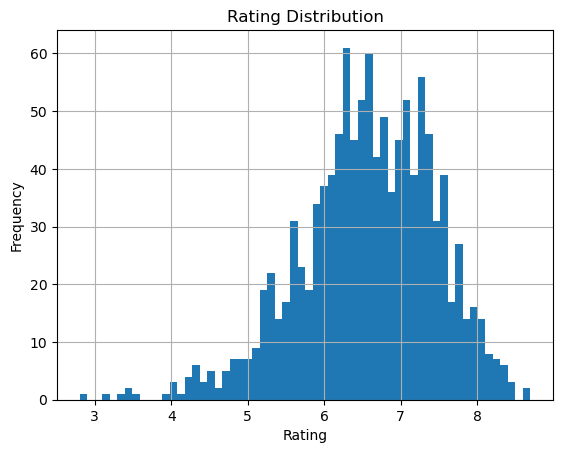

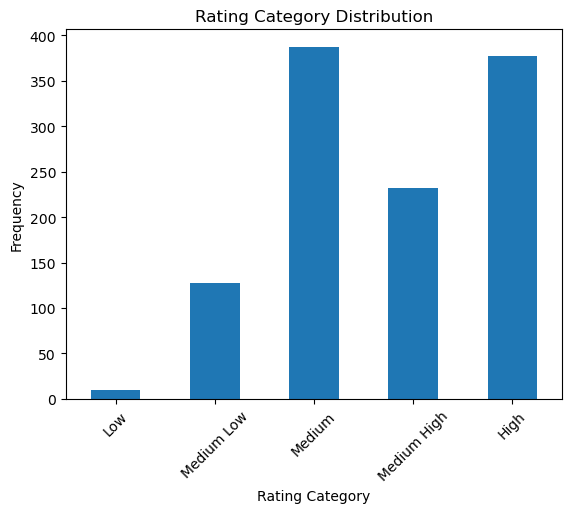

In [41]:
# plot rating distrbution
import matplotlib.pyplot as plt
df['rating'].hist(bins=60)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

# plot rating_category distribution
df['rating_category'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Category Distribution')
plt.xlabel('Rating Category')
plt.ylabel('Frequency')
plt.xticks(ticks=range(len(encoding)), labels=list(encoding.keys()), rotation=45)
plt.show()

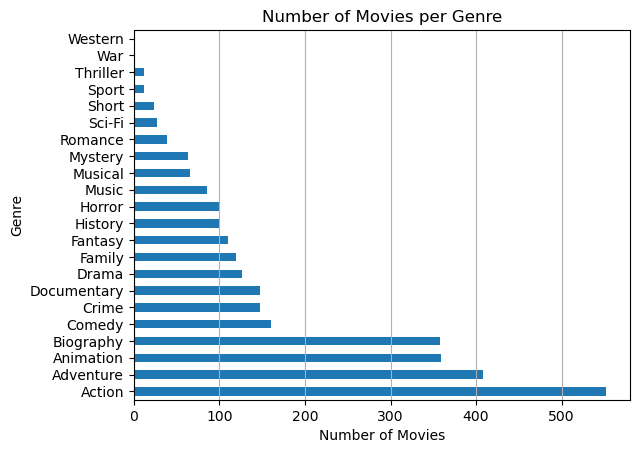

In [42]:
# on x axis the number of movies, on y axis the genre
df_genres.sum().sort_values(ascending=False).plot(kind='barh')
plt.title('Number of Movies per Genre')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
# remove the 'genre_' prefix from the labels
plt.yticks(ticks=range(len(df_genres.columns)), labels=[col.replace('genre_', '') for col in df_genres.columns])
# add grid
plt.grid(axis='x')
plt.show()

In [43]:
# create a list of columns that has a number in their name
columns_with_numbers = [col for col in df.columns if any(char.isdigit() for char in col)]

print("Columns with numbers in their names:")
print(columns_with_numbers)

Columns with numbers in their names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from tslearn.metrics import dtw, cdist_dtw
import seaborn as sns
from scipy.stats import zscore

X_flat = df[columns_with_numbers].values
X_flat = zscore(X_flat, axis=0)

dtw_distances = cdist_dtw(X_flat)

condensed_distances = squareform(dtw_distances, checks=False)

print("Condensed distances shape:", condensed_distances.shape)

KeyboardInterrupt: 

In [ ]:
from tslearn.metrics import dtw_path

def compute_constrained_sakoe_chiba(X, window=7):
    """Calcola matrice DTW con constraint specifici"""
    n = len(X)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Sakoe-Chiba band
            radius = int(window * len(X[i]))
            dist = dtw(X[i], X[j], sakoe_chiba_radius=radius)            
            distance_matrix[i, j] = dist
            distance_matrix[j, i] = dist
    
    return distance_matrix

In [ ]:
print("Computing DTW distances with Sakoe-Chiba constraints...")
dist_dtw   = cdist_dtw(X_flat)
print("DTW distances computed.")
dist_dtw_3 = compute_constrained_sakoe_chiba(X_flat, window=0.03)
print("DTW distances with Sakoe-Chiba (window=0.03) computed.")
dist_dtw_5 = compute_constrained_sakoe_chiba(X_flat, window=0.05)
print("DTW distances with Sakoe-Chiba (window=0.05) computed.")
dist_dtw_7 = compute_constrained_sakoe_chiba(X_flat, window=0.07)
print("DTW distances with Sakoe-Chiba (window=0.07) computed.")
dist_dtw_9 = compute_constrained_sakoe_chiba(X_flat, window=0.09)
print("DTW distances with Sakoe-Chiba (window=0.09) computed.")
dist_dtw_11 = compute_constrained_sakoe_chiba(X_flat, window=0.11)
print("DTW distances with Sakoe-Chiba (window=0.11) computed.")


Computing DTW distances with Sakoe-Chiba constraints...
DTW distances computed.
DTW distances with Sakoe-Chiba (window=0.03) computed.
DTW distances with Sakoe-Chiba (window=0.05) computed.
DTW distances with Sakoe-Chiba (window=0.07) computed.
DTW distances with Sakoe-Chiba (window=0.09) computed.


Computing DTW...
Computing Sakoe-Chiba (window=3)...
Computing Sakoe-Chiba (window=5)...
Computing Sakoe-Chiba (window=7)...
Computing Sakoe-Chiba (window=9)...


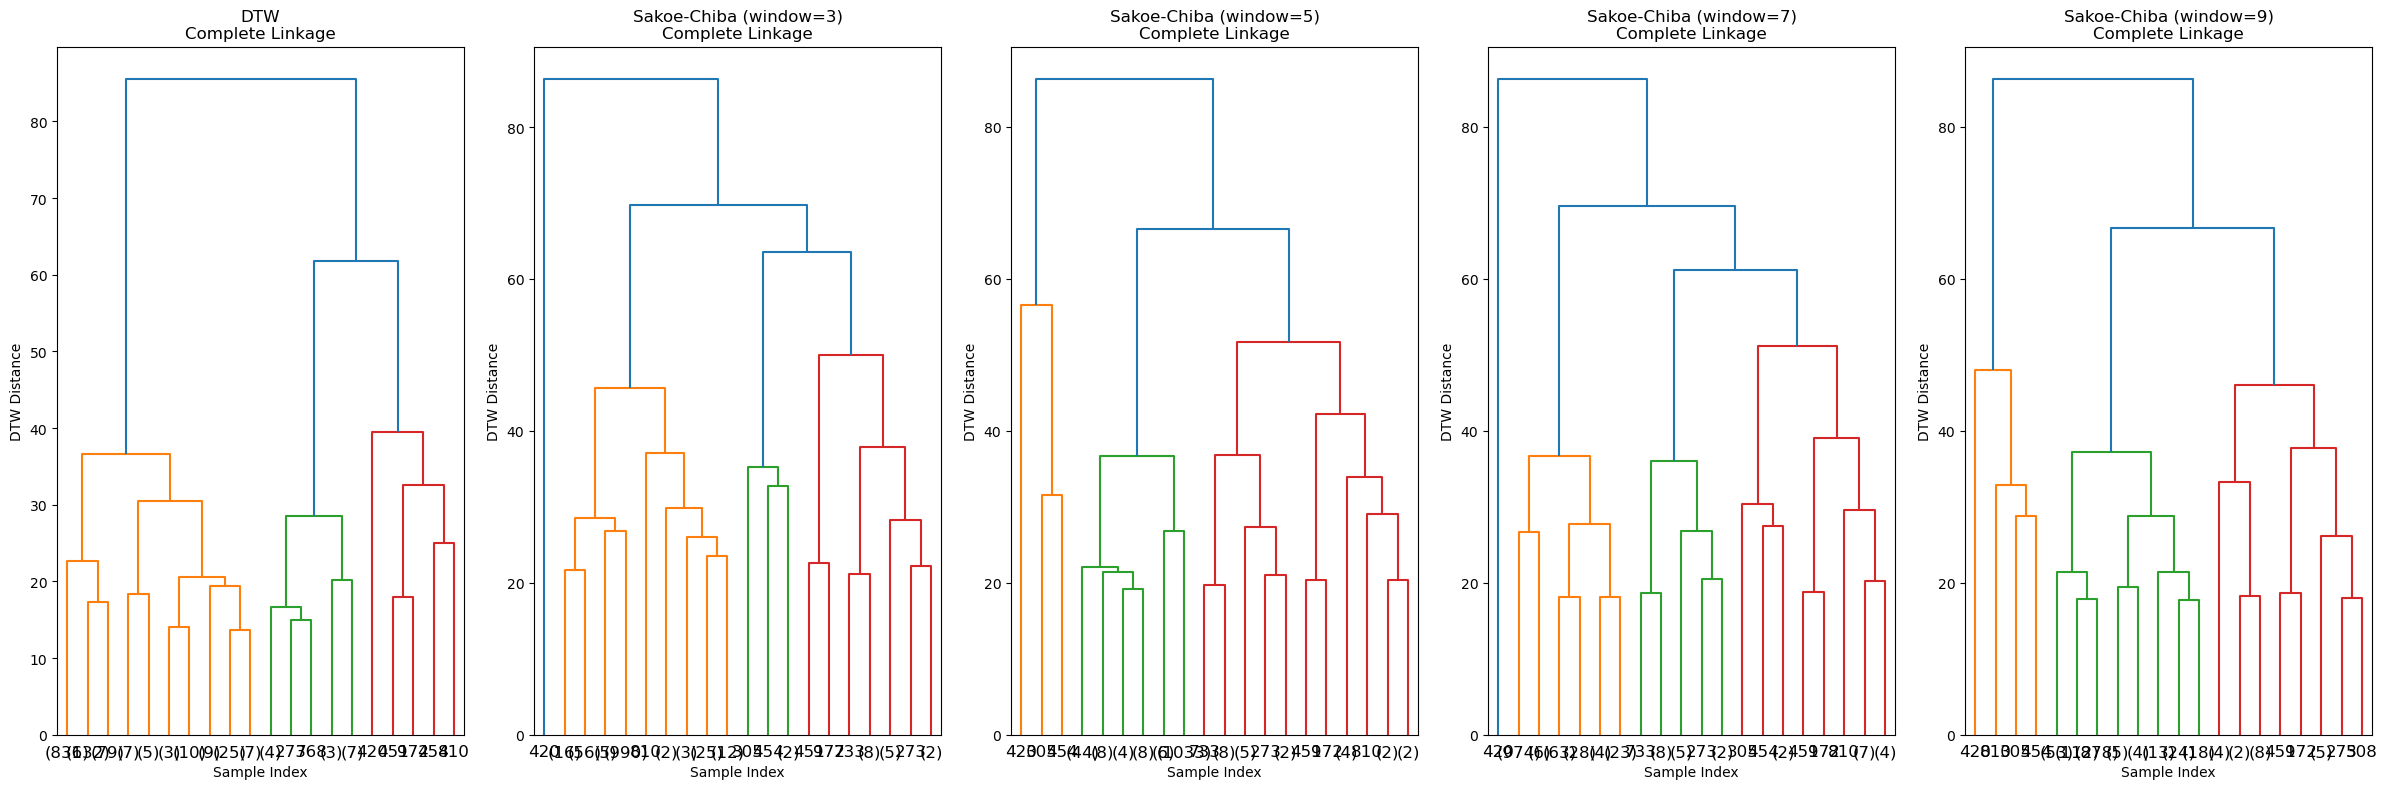

In [ ]:

dtw_variants = [
    ('DTW', dist_dtw),
    ('Sakoe-Chiba (window=3)', dist_dtw_3),
    ('Sakoe-Chiba (window=5)', dist_dtw_5),
    ('Sakoe-Chiba (window=7)', dist_dtw_7),  # Solo 4 per il subplot 1x4
    ('Sakoe-Chiba (window=9)', dist_dtw_9),
    ('Sakoe-Chiba (window=11)', dist_dtw_11)  # Aggiunto un altro per completare il subplot
]

fig, axes = plt.subplots(1, 5, figsize=(24, 8))

for idx, (name, dist_matrix) in enumerate(dtw_variants):  # ← CAMBIA: constraint → dist_matrix
    print(f"Computing {name}...")
    
    # Clustering gerarchico
    condensed_dist = squareform(dist_matrix, checks=False)  # ← ORA usa la matrice corretta
    Z = linkage(condensed_dist, method='complete')
    
    # Plot dendrogramma
    dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=20)
    axes[idx].set_title(f'{name}\nComplete Linkage')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('DTW Distance')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def calculate_metrics(distance_matrix, cluster_labels):
    """
    Calcola le metriche di clustering: cohesion_ratio, separation_ratio e quality_score.
    
    Parameters:
    - distance_matrix: matrice delle distanze tra i punti
    - cluster_labels: etichette dei cluster per ogni punto
    
    Returns:
    - metrics: dizionario con cohesion_ratio, separation_ratio e quality_score
    """
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    
    # Calcola la coesione (intra-cluster)
    cohesion = 0
    for cluster in unique_clusters:
        cluster_points = np.where(cluster_labels == cluster)[0]
        intra_distances = distance_matrix[np.ix_(cluster_points, cluster_points)]
        cohesion += np.sum(intra_distances) / len(cluster_points)
    cohesion_ratio = cohesion / n_clusters
    
    # Calcola la separazione (inter-cluster)
    cluster_centers = []
    for cluster in unique_clusters:
        cluster_points = np.where(cluster_labels == cluster)[0]
        cluster_center = np.mean(distance_matrix[cluster_points], axis=0)
        cluster_centers.append(cluster_center)
    cluster_centers = np.array(cluster_centers)
    
    separation = 0
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            separation += np.linalg.norm(cluster_centers[i] - cluster_centers[j])
    separation_ratio = separation / (n_clusters * (n_clusters - 1) / 2)
    
    # Calcola il quality score
    quality_score = separation_ratio / cohesion_ratio
    
    return {
        'cohesion_ratio': cohesion_ratio,
        'separation_ratio': separation_ratio,
        'quality_score': quality_score
    }

# Esempio di utilizzo
# Supponiamo che `distance_matrix` sia la matrice delle distanze e `cluster_labels` siano le etichette dei cluster
distance_matrix = dist_dtw  # Usa la matrice delle distanze DTW
cluster_labels = np.random.randint(0, 5, size=distance_matrix.shape[0])  # Esempio di etichette dei cluster

metrics = calculate_metrics(distance_matrix, cluster_labels)

# Analisi specifica per threshold 45, 50, 55
recommended_thresholds = [15, 20, 25, 30, 35, 40, 45, 50, 55]

print("🎯 ANALISI THRESHOLD RACCOMANDATE:")
print("="*50)

for threshold in recommended_thresholds:
    method_name = 'DTW Standard'
    all_scores = outlier_results[method_name]['all_scores']
    n_outliers = np.sum(all_scores > threshold)
    percentage = (n_outliers / len(all_scores)) * 100
    
    # Trova l'indice nel metrics_data
    threshold_idx = metrics_data['thresholds'].index(threshold) if threshold in metrics_data['thresholds'] else None
    
    if threshold_idx is not None:
        cohesion = metrics_data['cohesion_ratio'][threshold_idx]
        separation = metrics_data['separation_ratio'][threshold_idx]
        quality = metrics_data['quality_score'][threshold_idx]
        
        print(f"\n📊 THRESHOLD {threshold}:")
        print(f"   Outlier identificati: {n_outliers} ({percentage:.1f}%)")
        print(f"   Cohesion Ratio: {cohesion:.2f}")
        print(f"   Separation Ratio: {separation:.2f}")
        print(f"   Quality Score: {quality:.2f}")
        
        # Interpretazione
        if cohesion < 5.0 and separation > 7.0:
            print(f"   ✅ BUONA SCELTA: Bilanciamento ottimale")
        else:
            print(f"   ⚠️  Da valutare")

🎯 ANALISI THRESHOLD RACCOMANDATE:

📊 THRESHOLD 15:
   Outlier identificati: 92 (8.1%)
   Cohesion Ratio: 4.14
   Separation Ratio: 6.93
   Quality Score: 1.68
   ⚠️  Da valutare

📊 THRESHOLD 20:
   Outlier identificati: 57 (5.0%)
   Cohesion Ratio: 4.08
   Separation Ratio: 7.43
   Quality Score: 1.82
   ✅ BUONA SCELTA: Bilanciamento ottimale

📊 THRESHOLD 25:
   Outlier identificati: 38 (3.4%)
   Cohesion Ratio: 4.07
   Separation Ratio: 8.03
   Quality Score: 1.97
   ✅ BUONA SCELTA: Bilanciamento ottimale

📊 THRESHOLD 30:
   Outlier identificati: 25 (2.2%)
   Cohesion Ratio: 4.13
   Separation Ratio: 8.33
   Quality Score: 2.02
   ✅ BUONA SCELTA: Bilanciamento ottimale

📊 THRESHOLD 35:
   Outlier identificati: 19 (1.7%)
   Cohesion Ratio: 4.27
   Separation Ratio: 9.09
   Quality Score: 2.13
   ✅ BUONA SCELTA: Bilanciamento ottimale

📊 THRESHOLD 40:
   Outlier identificati: 15 (1.3%)
   Cohesion Ratio: 4.05
   Separation Ratio: 8.47
   Quality Score: 2.09
   ✅ BUONA SCELTA: Bilanciame

In [ ]:
t = 32
# Visualizza gli outlier per threshold 50
print(f"\n📈 OUTLIER con THRESHOLD:")
threshold_outliers_50 = np.where(outlier_results['DTW Standard']['all_scores'] >= t)[0]
print(f"Indici: {threshold_outliers_50.tolist()}")
print(f"Numero: {len(threshold_outliers_50)}")

threshold_outliers_3 = np.where(outlier_results['Sakoe-Chiba (window=3%)']['all_scores'] >= t)[0]
print(f"\n📈 OUTLIER con THRESHOLD (Sakoe-Chiba 3%):")
print(f"Indici: {threshold_outliers_3.tolist()}")
print(f"Numero: {len(threshold_outliers_3)}")

threshold_outliers_5 = np.where(outlier_results['Sakoe-Chiba (window=5%)']['all_scores'] >= t)[0]
print(f"\n📈 OUTLIER con THRESHOLD (Sakoe-Chiba 5%):")
print(f"Indici: {threshold_outliers_5.tolist()}")
print(f"Numero: {len(threshold_outliers_5)}")

threshold_outliers_7 = np.where(outlier_results['Sakoe-Chiba (window=7%)']['all_scores'] >= t)[0]
print(f"\n📈 OUTLIER con THRESHOLD (Sakoe-Chiba 7%):")
print(f"Indici: {threshold_outliers_7.tolist()}")
print(f"Numero: {len(threshold_outliers_7)}")

threshold_outliers_9 = np.where(outlier_results['Sakoe-Chiba (window=9%)']['all_scores'] >= t)[0]
print(f"\n📈 OUTLIER con THRESHOLD (Sakoe-Chiba 9%):")
print(f"Indici: {threshold_outliers_9.tolist()}")
print(f"Numero: {len(threshold_outliers_9)}")


📈 OUTLIER con THRESHOLD:
Indici: [5, 73, 235, 273, 305, 325, 420, 425, 451, 454, 508, 511, 676, 694, 732, 733, 768, 810, 939, 972]
Numero: 20

📈 OUTLIER con THRESHOLD (Sakoe-Chiba 3%):
Indici: [5, 73, 235, 273, 305, 325, 420, 425, 451, 454, 508, 511, 664, 676, 694, 732, 733, 768, 810, 939, 972, 1086]
Numero: 22

📈 OUTLIER con THRESHOLD (Sakoe-Chiba 5%):
Indici: [5, 73, 235, 273, 305, 325, 420, 425, 451, 454, 508, 511, 664, 676, 694, 732, 733, 768, 810, 939, 972, 1086]
Numero: 22

📈 OUTLIER con THRESHOLD (Sakoe-Chiba 7%):
Indici: [5, 73, 235, 273, 305, 325, 420, 425, 451, 454, 508, 511, 664, 676, 694, 732, 733, 768, 810, 939, 972, 1086]
Numero: 22

📈 OUTLIER con THRESHOLD (Sakoe-Chiba 9%):
Indici: [5, 73, 235, 273, 305, 325, 420, 425, 451, 454, 508, 511, 664, 676, 694, 732, 733, 768, 810, 939, 972, 1086]
Numero: 22


🚀 AVVIO ANALISI OUTLIER vs THRESHOLD (15-50)
📊 ANALISI OUTLIER vs THRESHOLD (da 15 a 50)


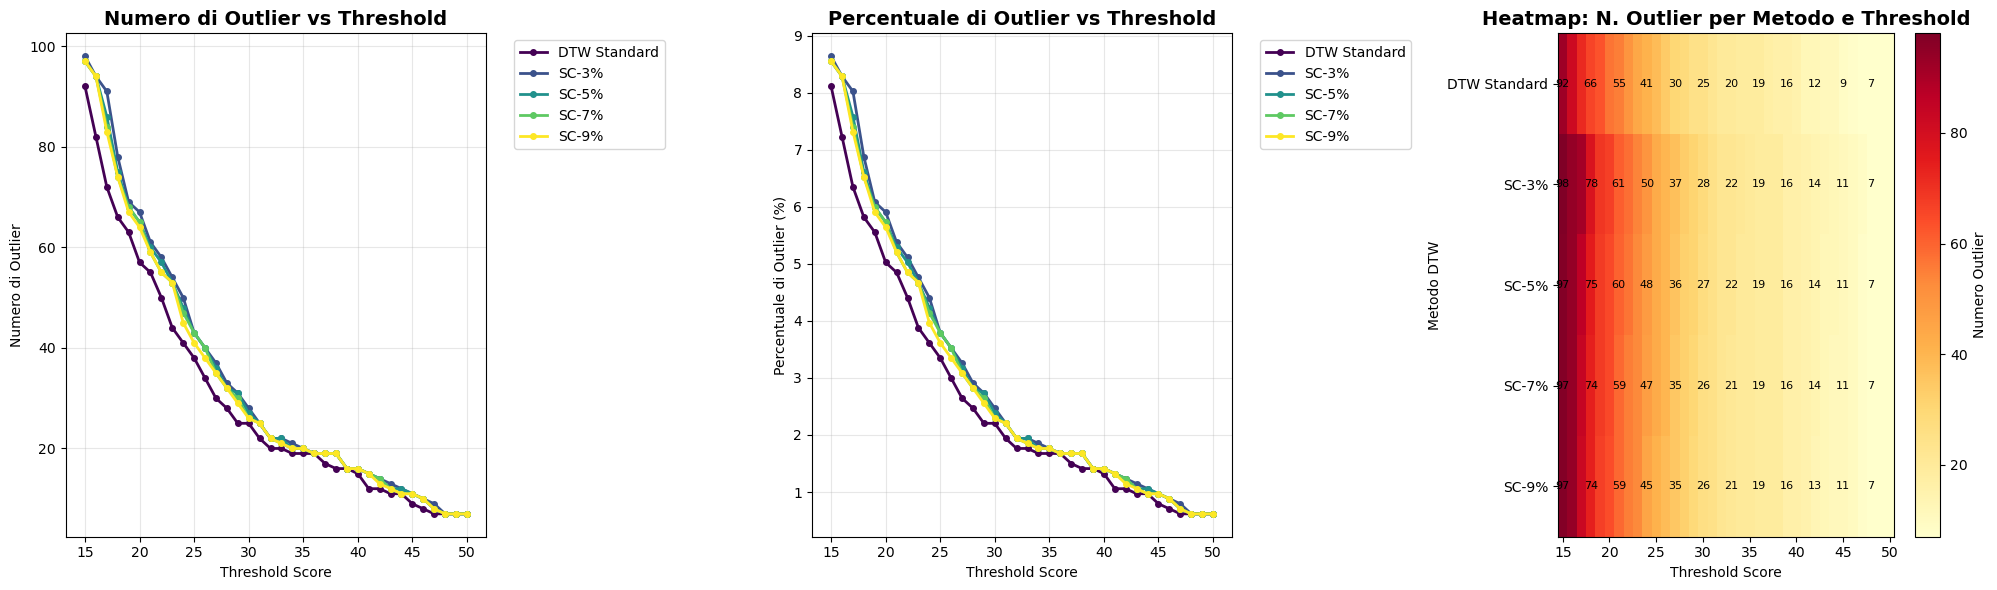


📋 RIASSUNTO THRESHOLD CHIAVE:
Threshold  DTW Std  SC-3%    SC-5%    SC-7%    SC-9%   
--------------------------------------------------------------------------------
15        92      98      97      97      97      
20        57      67      65      65      64      
25        38      43      43      43      41      
30        25      28      27      26      26      
35        19      20      20      20      20      
40        15      16      16      16      16      
45        9       11      11      11      11      
50        7       7       7       7       7       

🔍 CONSISTENZA TRA METODI:
--------------------------------------------------
T=15: Min=92, Max=98, Range= 6, Var=4.6
T=20: Min=57, Max=67, Range=10, Var=11.8
T=25: Min=38, Max=43, Range= 5, Var=3.8
T=30: Min=25, Max=28, Range= 3, Var=1.0
T=35: Min=19, Max=20, Range= 1, Var=0.2
T=40: Min=15, Max=16, Range= 1, Var=0.2
T=45: Min= 9, Max=11, Range= 2, Var=0.6
T=50: Min= 7, Max= 7, Range= 0, Var=0.0

🎯 ANALISI CONSISTENZA OU

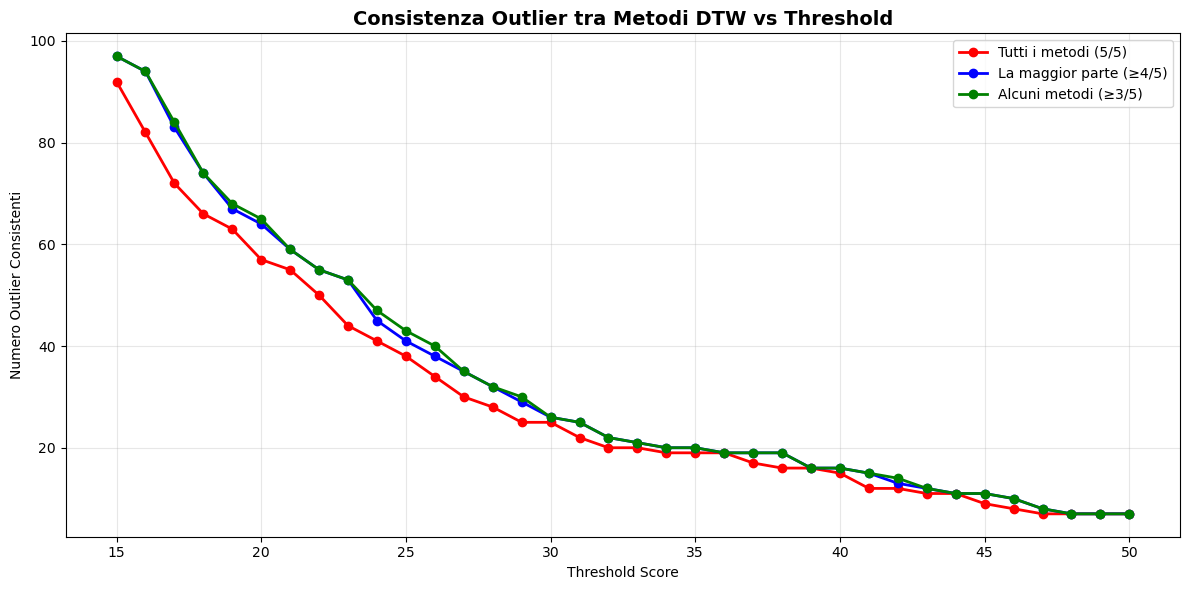

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_outliers_vs_threshold(outlier_results, threshold_range=range(15, 51)):
    """
    Plotta il numero di outlier per ogni metodo DTW al variare della threshold
    """
    
    print(f"📊 ANALISI OUTLIER vs THRESHOLD (da {min(threshold_range)} a {max(threshold_range)})")
    print("="*70)
    
    methods = list(outlier_results.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(methods)))
    
    # Prepara i dati
    data = {}
    for method in methods:
        data[method] = {
            'thresholds': list(threshold_range),
            'n_outliers': [],
            'percentages': []
        }
        
        all_scores = outlier_results[method]['all_scores']
        total_samples = len(all_scores)
        
        for threshold in threshold_range:
            n_outliers = np.sum(all_scores >= threshold)
            percentage = (n_outliers / total_samples) * 100
            
            data[method]['n_outliers'].append(n_outliers)
            data[method]['percentages'].append(percentage)
    
    # Crea la figura con 3 subplot
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # 1. Numero assoluto di outlier
    ax1 = axes[0]
    for i, method in enumerate(methods):
        thresholds = data[method]['thresholds']
        n_outliers = data[method]['n_outliers']
        ax1.plot(thresholds, n_outliers, 'o-', color=colors[i], 
                label=method.replace('Sakoe-Chiba (window=', 'SC-').replace('%)', '%'),
                linewidth=2, markersize=4)
    
    ax1.set_title('Numero di Outlier vs Threshold', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Threshold Score')
    ax1.set_ylabel('Numero di Outlier')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(range(15, 51, 5))
    
    # 2. Percentuale di outlier
    ax2 = axes[1]
    for i, method in enumerate(methods):
        thresholds = data[method]['thresholds']
        percentages = data[method]['percentages']
        ax2.plot(thresholds, percentages, 'o-', color=colors[i], 
                label=method.replace('Sakoe-Chiba (window=', 'SC-').replace('%)', '%'),
                linewidth=2, markersize=4)
    
    ax2.set_title('Percentuale di Outlier vs Threshold', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Threshold Score')
    ax2.set_ylabel('Percentuale di Outlier (%)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(15, 51, 5))
    
    # 3. Heatmap per visualizzazione compatta
    ax3 = axes[2]
    
    # Crea matrice per heatmap
    threshold_list = list(threshold_range)
    outlier_matrix = np.array([data[method]['n_outliers'] for method in methods])
    
    im = ax3.imshow(outlier_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')
    ax3.set_title('Heatmap: N. Outlier per Metodo e Threshold', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Threshold Score')
    ax3.set_ylabel('Metodo DTW')
    
    # Etichette asse y
    ax3.set_yticks(range(len(methods)))
    ax3.set_yticklabels([method.replace('Sakoe-Chiba (window=', 'SC-').replace('%)', '%') 
                         for method in methods])
    
    # Etichette asse x (ogni 5)
    step = 5
    tick_indices = [i for i, t in enumerate(threshold_list) if t % step == 0]
    ax3.set_xticks(tick_indices)
    ax3.set_xticklabels([threshold_list[i] for i in tick_indices])
    
    # Aggiungi numeri nella heatmap
    for i in range(len(methods)):
        for j in range(len(threshold_list)):
            if j % 3 == 0:  # Mostra solo ogni 3 valori per non affollare
                text = ax3.text(j, i, f'{outlier_matrix[i, j]}',
                               ha="center", va="center", color="black", fontsize=8)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax3)
    cbar.set_label('Numero Outlier')
    
    plt.tight_layout()
    plt.show()
    
    return data

def print_threshold_summary(data, key_thresholds=[15, 20, 25, 30, 35, 40, 45, 50]):
    """
    Stampa un riassunto per threshold specifiche
    """
    
    print(f"\n📋 RIASSUNTO THRESHOLD CHIAVE:")
    print("="*80)
    print(f"{'Threshold':<10} {'DTW Std':<8} {'SC-3%':<8} {'SC-5%':<8} {'SC-7%':<8} {'SC-9%':<8}")
    print("-" * 80)
    
    methods = list(data.keys())
    method_short = ['DTW Std', 'SC-3%', 'SC-5%', 'SC-7%', 'SC-9%']
    
    for threshold in key_thresholds:
        if threshold in data[methods[0]]['thresholds']:
            idx = data[methods[0]]['thresholds'].index(threshold)
            row = f"{threshold:<10}"
            
            for method in methods:
                n_outliers = data[method]['n_outliers'][idx]
                row += f"{n_outliers:<8}"
            
            print(row)
    
    # Analisi delle differenze tra metodi
    print(f"\n🔍 CONSISTENZA TRA METODI:")
    print("-" * 50)
    
    for threshold in key_thresholds:
        if threshold in data[methods[0]]['thresholds']:
            idx = data[methods[0]]['thresholds'].index(threshold)
            outlier_counts = [data[method]['n_outliers'][idx] for method in methods]
            
            min_count = min(outlier_counts)
            max_count = max(outlier_counts)
            variance = np.var(outlier_counts)
            
            print(f"T={threshold:2d}: Min={min_count:2d}, Max={max_count:2d}, "
                  f"Range={max_count-min_count:2d}, Var={variance:.1f}")

def identify_outlier_consistency_by_threshold(outlier_results, threshold_range=range(15, 51)):
    """
    Identifica outlier consistenti tra metodi per ogni threshold
    """
    
    print(f"\n🎯 ANALISI CONSISTENZA OUTLIER TRA METODI:")
    print("="*60)
    
    methods = list(outlier_results.keys())
    consistency_data = {}
    
    for threshold in threshold_range:
        # Per ogni threshold, trova outlier comuni
        method_outliers = {}
        for method in methods:
            all_scores = outlier_results[method]['all_scores']
            outliers = np.where(all_scores >= threshold)[0]
            method_outliers[method] = set(outliers)
        
        # Trova intersezioni
        all_outliers = set()
        for outliers in method_outliers.values():
            all_outliers.update(outliers)
        
        # Conta frequenza di ogni outlier
        outlier_frequency = {}
        for outlier in all_outliers:
            count = sum(1 for outliers in method_outliers.values() if outlier in outliers)
            outlier_frequency[outlier] = count
        
        # Statistiche di consistenza
        consistent_all = [idx for idx, freq in outlier_frequency.items() if freq == len(methods)]
        consistent_most = [idx for idx, freq in outlier_frequency.items() if freq >= 4]
        consistent_some = [idx for idx, freq in outlier_frequency.items() if freq >= 3]
        
        consistency_data[threshold] = {
            'all_methods': len(consistent_all),
            'most_methods': len(consistent_most),
            'some_methods': len(consistent_some),
            'total_unique': len(all_outliers)
        }
        
        if threshold % 10 == 0:  # Print ogni 10
            print(f"T={threshold}: Tutti={len(consistent_all)}, ≥4={len(consistent_most)}, "
                  f"≥3={len(consistent_some)}, Tot={len(all_outliers)}")
    
    return consistency_data

# Esegui l'analisi completa
print("🚀 AVVIO ANALISI OUTLIER vs THRESHOLD (15-50)")

# Plot principale
data = plot_outliers_vs_threshold(outlier_results, threshold_range=range(15, 51))

# Riassunto threshold chiave
print_threshold_summary(data)

# Analisi consistenza
consistency_data = identify_outlier_consistency_by_threshold(outlier_results, threshold_range=range(15, 51))

# Plot consistenza
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

thresholds = list(consistency_data.keys())
all_methods = [consistency_data[t]['all_methods'] for t in thresholds]
most_methods = [consistency_data[t]['most_methods'] for t in thresholds]
some_methods = [consistency_data[t]['some_methods'] for t in thresholds]

ax.plot(thresholds, all_methods, 'ro-', label='Tutti i metodi (5/5)', linewidth=2, markersize=6)
ax.plot(thresholds, most_methods, 'bo-', label='La maggior parte (≥4/5)', linewidth=2, markersize=6)
ax.plot(thresholds, some_methods, 'go-', label='Alcuni metodi (≥3/5)', linewidth=2, markersize=6)

ax.set_title('Consistenza Outlier tra Metodi DTW vs Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Threshold Score')
ax.set_ylabel('Numero Outlier Consistenti')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(15, 51, 5))

plt.tight_layout()
plt.show()

In [ ]:
# remove from dataset the outliers identified with threshold 45
def remove_outliers_from_dataset(X_flat, outlier_indices):
    """
    Rimuove gli outlier identificati dagli indici dal dataset
    """
    
    print(f"🔍 RIMOZIONE OUTLIER DAL DATASET ({len(outlier_indices)} outlier)")
    
    # Crea una maschera booleana per i normali
    mask = np.ones(X_flat.shape[0], dtype=bool)
    mask[outlier_indices] = False  # Imposta gli outlier a False
    
    # Filtra il dataset
    X_filtered = X_flat[mask]
    
    print(f"Dataset originale: {X_flat.shape}, Dataset filtrato: {X_filtered.shape}")
    
    return X_filtered

# Rimuovi gli outlier identificati con threshold 45
_X_flat = remove_outliers_from_dataset(X_flat, threshold_outliers_3)


🔍 RIMOZIONE OUTLIER DAL DATASET (22 outlier)
Dataset originale: (1134, 100), Dataset filtrato: (1112, 100)


In [ ]:
print("Computing DTW distances with Sakoe-Chiba constraints...")
dist_dtw   = cdist_dtw(_X_flat)
print("DTW distances computed.")
dist_dtw_3 = compute_constrained_sakoe_chiba(_X_flat, window=0.03)
print("DTW distances with Sakoe-Chiba (window=0.03) computed.")
dist_dtw_5 = compute_constrained_sakoe_chiba(_X_flat, window=0.05)
print("DTW distances with Sakoe-Chiba (window=0.05) computed.")
dist_dtw_7 = compute_constrained_sakoe_chiba(_X_flat, window=0.07)
print("DTW distances with Sakoe-Chiba (window=0.07) computed.")
dist_dtw_9 = compute_constrained_sakoe_chiba(_X_flat, window=0.09)
print("DTW distances with Sakoe-Chiba (window=0.09) computed.")
dist_dtw_11 = compute_constrained_sakoe_chiba(_X_flat, window=0.11)
print("DTW distances with Sakoe-Chiba (window=0.11) computed.")
dtw_variants = [
    ('DTW', dist_dtw),
    ('Sakoe-Chiba (window=3)', dist_dtw_3),
    ('Sakoe-Chiba (window=5)', dist_dtw_5),
    ('Sakoe-Chiba (window=7)', dist_dtw_7),  # Solo 4 per il subplot 1x4
    ('Sakoe-Chiba (window=9)', dist_dtw_9),
    ('Sakoe-Chiba (window=11)', dist_dtw_11)
]
 

Computing DTW distances with Sakoe-Chiba constraints...
DTW distances computed.
DTW distances with Sakoe-Chiba (window=0.03) computed.
DTW distances with Sakoe-Chiba (window=0.05) computed.
DTW distances with Sakoe-Chiba (window=0.07) computed.
DTW distances with Sakoe-Chiba (window=0.09) computed.
DTW distances with Sakoe-Chiba (window=0.11) computed.


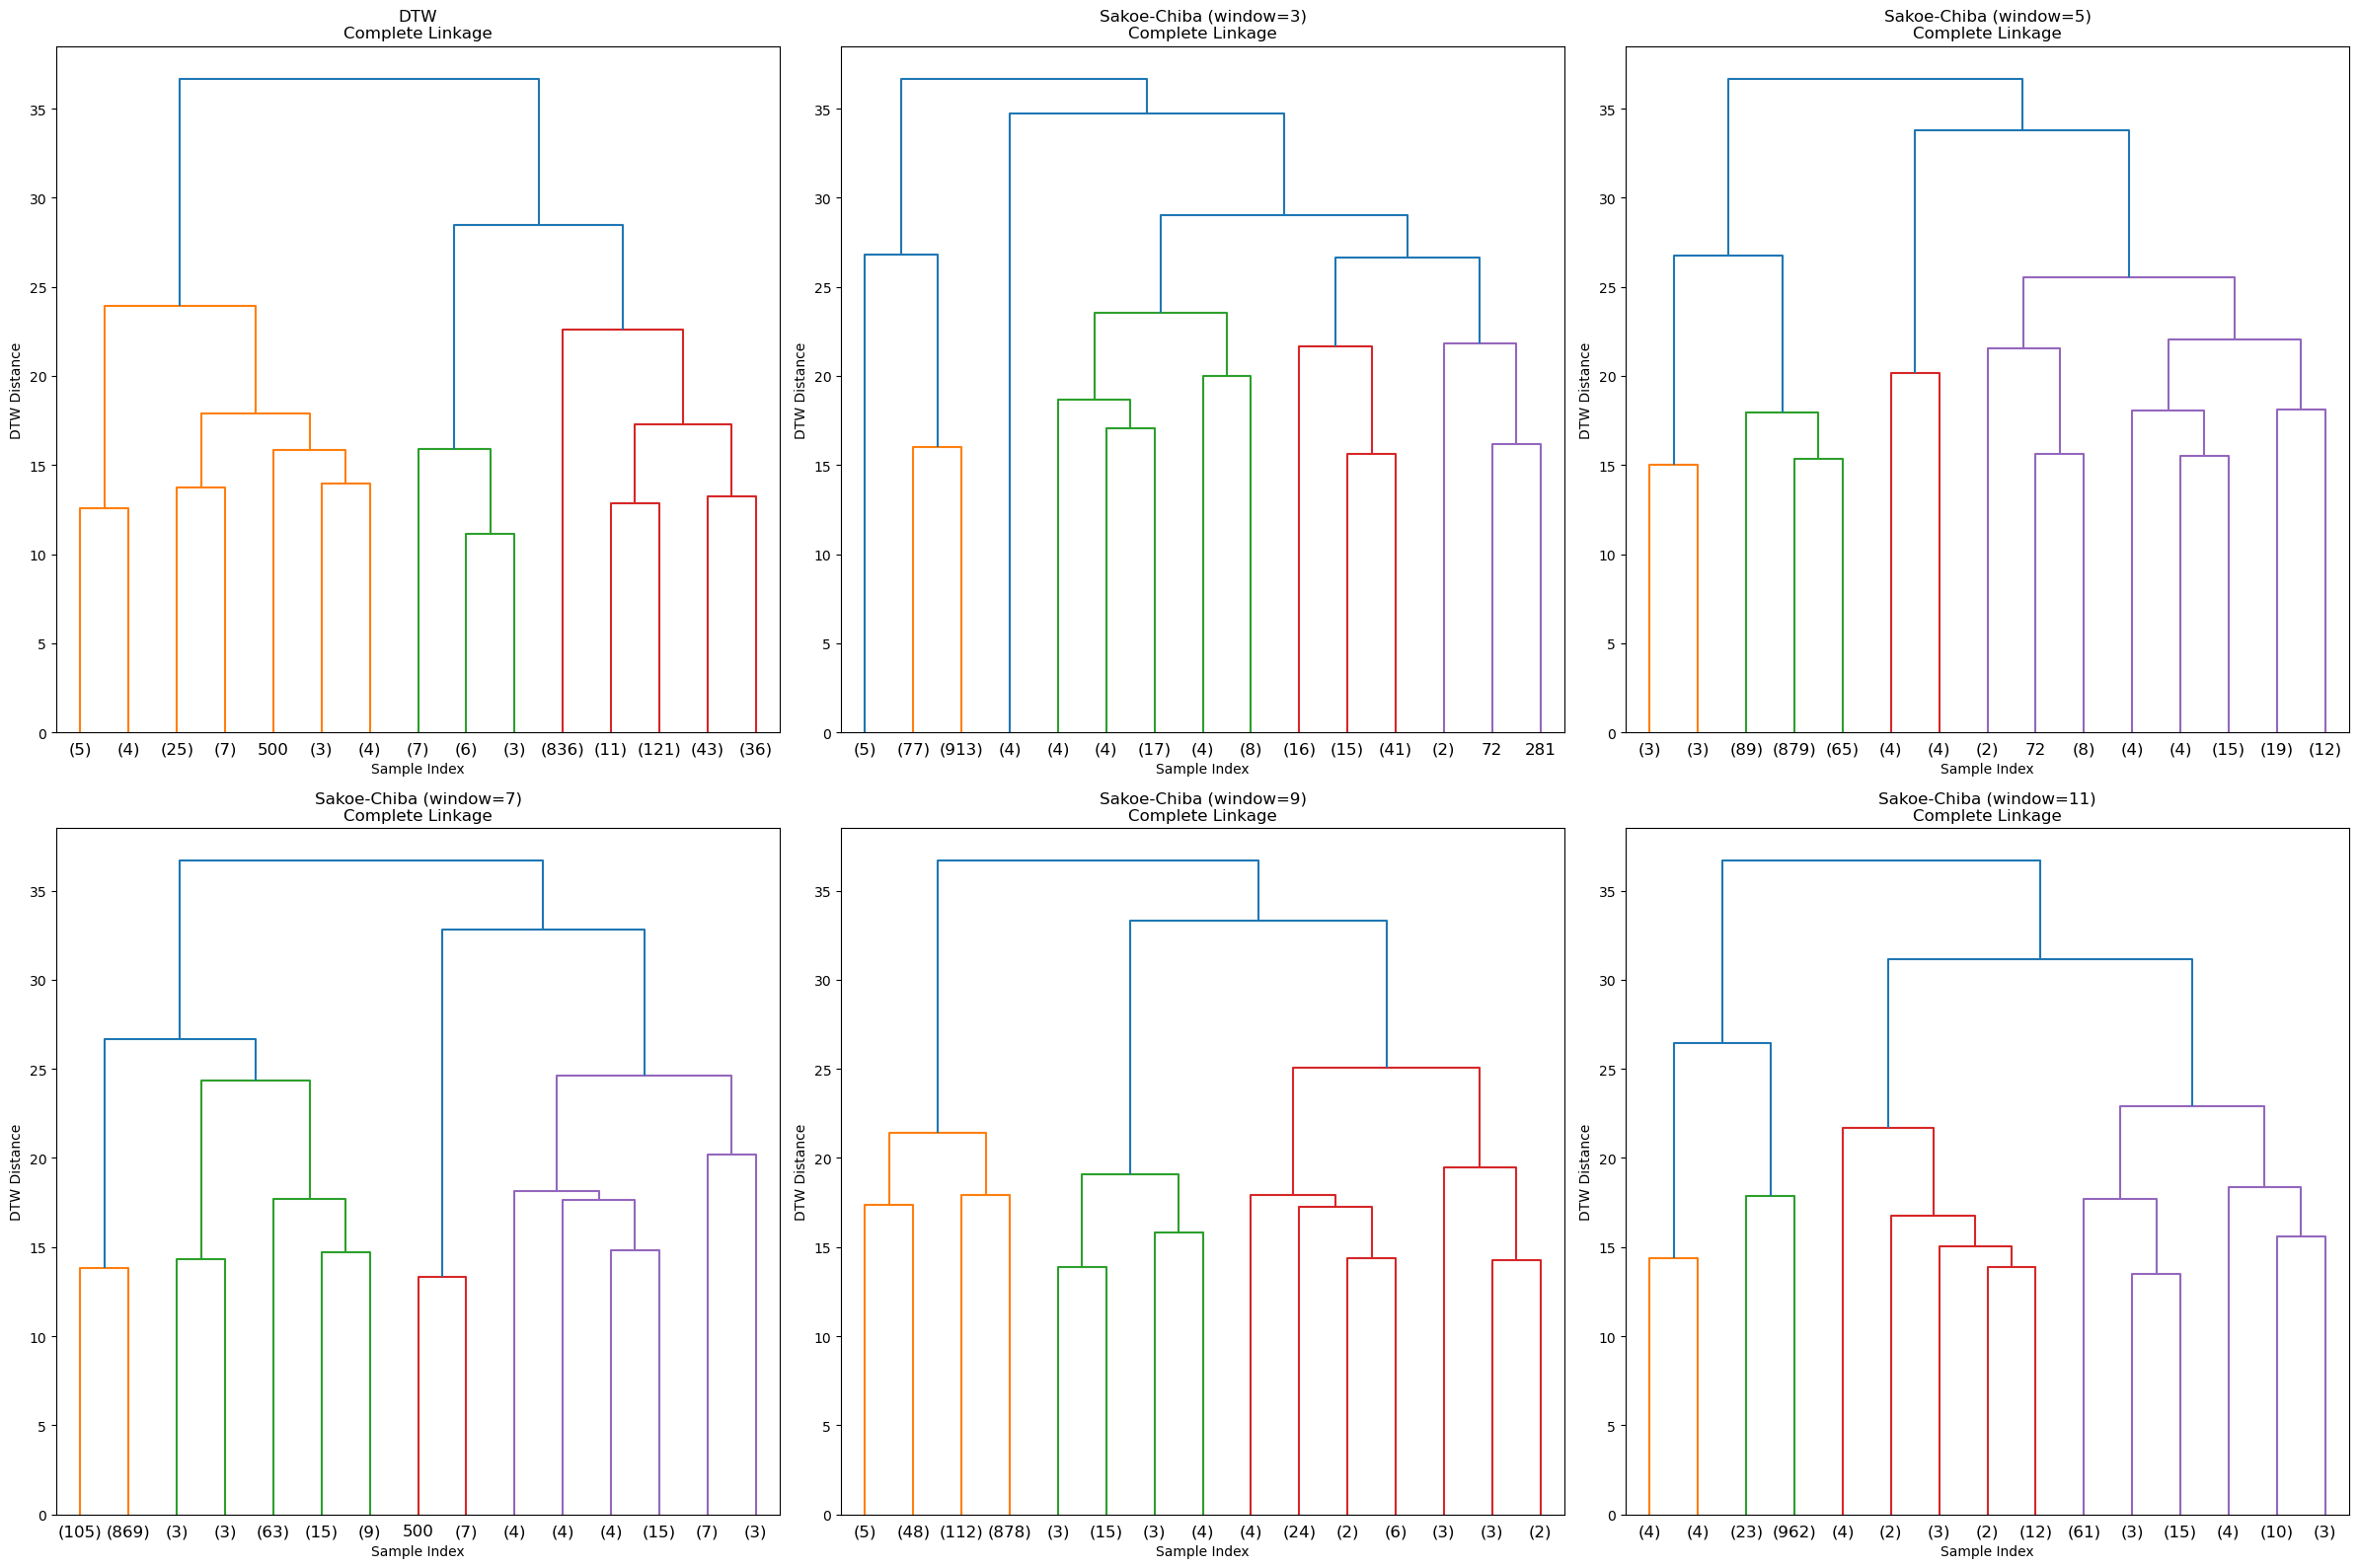

In [ ]:
dtw_variants = [
    ('DTW', dist_dtw),
    ('Sakoe-Chiba (window=3)', dist_dtw_3),
    ('Sakoe-Chiba (window=5)', dist_dtw_5),
    ('Sakoe-Chiba (window=7)', dist_dtw_7),
    ('Sakoe-Chiba (window=9)', dist_dtw_9),
    ('Sakoe-Chiba (window=11)', dist_dtw_11)
]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))  # Griglia 2x3

for idx, (name, dist_matrix) in enumerate(dtw_variants):
    row, col = divmod(idx, 3)  # Calcola la posizione nella griglia
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='complete')
    
    # Plot dendrogramma
    dendrogram(Z, ax=axes[row, col], truncate_mode='lastp', p=15)
    axes[row, col].set_title(f'{name}\nComplete Linkage')
    axes[row, col].set_xlabel('Sample Index')
    axes[row, col].set_ylabel('DTW Distance')

plt.tight_layout()
plt.show()

In [178]:
import pandas as pd
import numpy as np

def store_dataset_without_outliers(df, outlier_indices, output):
    """
    Salva il dataset senza outlier in due file CSV: uno normalizzato e uno non normalizzato.
    
    Parameters:
    - df: DataFrame originale
    - outlier_indices: indici delle righe da rimuovere (outlier)
    - filename_normalized: nome del file per il dataset normalizzato
    - filename_unnormalized: nome del file per il dataset non normalizzato
    """
    # Rimuovi gli outlier dal DataFrame originale
    df_no_outliers = df.drop(index=outlier_indices).reset_index(drop=True)
    
    # store unnormalized dataset
    df_no_outliers.to_csv(output, index=False)    
    
store_dataset_without_outliers(df, threshold_outliers_3, output='TS_NO_OUTLIERS.csv')